In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX;

┌ Info: Precompiling JJDFTX [0d21db8c-e7cb-497b-98f4-4306b49e2569]
└ @ Base loading.jl:1317


Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
export_hwannier("wannier", spin=Val('n'));
export_momentum("wannier", spin=Val('n'));
export_heph("wannier", spin=Val('n'));

In [4]:
Hwannier, cell_map = hwannier("wannier"), np.loadtxt("wannier.map.txt")
Pwannier = pwannier("wannier");
Heph, celleph_map = hephwannier("wannier"), np.loadtxt("wannier.mapeph.txt");

In [13]:
dirac_point = wannier_bands(Hwannier, cell_map, [2/3, -1/3, 0])[1][5]
lattice_vectors = loadlattice("graphene.out");

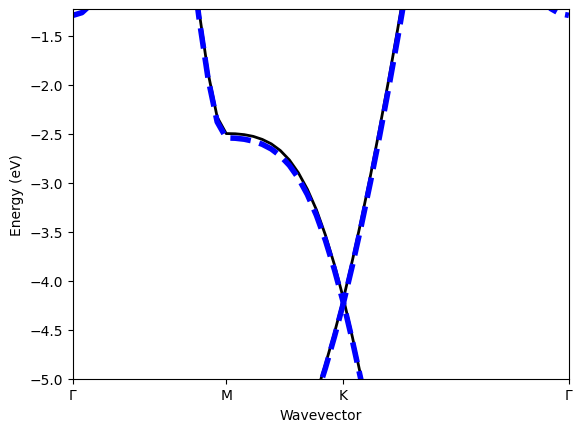

(-5.0, -1.2259635003760794)

In [80]:
plot_bands("graphene.bands.eigenvals", to_greek=true)
plot_bands(Hwannier, cell_map, linestyle="dashed", linewidth=4, color="blue")
ylim(-5, dirac_point+3)

In [154]:
function interbandsigma_graphene(lattice_vectors::Vector{<:Vector{Float64}}, Hwannier::Array{Float64, 3}, cell_map::Array{Float64, 2}, 
    Pwannier::Array{Float64, 4}, μ::Real, ::Val{D}=Val(2); mesh::Integer =10, num_blocks::Integer = 10,
    histogram_width::Integer=10, energy_range::Real=20, degeneracy::Integer=1, subsampling::Integer=10) where D

    V = D == 2 ? unit_cell_area(lattice_vectors) : unit_cell_volume(lattice_vectors)
    prefactor = degeneracy*4*π*ħ^2/V
    conds = zeros(ComplexF64, round(Int, histogram_width*energy_range))
    for i in 1:num_blocks
        println("Block: $i"); flush(stdout)
        ks =  (vcat(rand(D, mesh^D), zeros(3-D, mesh^D)) .- [1/2, 1/2, 0]) ./ subsampling .+ [2/3, -1/3, 0]
        Eks, Uks= wannier_bands(Hwannier, cell_map, ks);
        numbands = size(Eks)[2]
        Eksn = np.repeat(np.reshape(Eks, (-1, numbands, 1)), numbands, axis=2)
        Eksm = np.repeat(np.reshape(Eks, (-1, 1, numbands)), numbands, axis=1)
        vnks = momentum_matrix_elements(Uks, cell_map, Pwannier, ks)/mₑ
        omeganm = Eksn - Eksm
        weights = prefactor*histogram_width/mesh^D*np.einsum("knm, kpnm, krnm, knm -> kprnm", -np.heaviside(μ .- Eksn, 0.5)  + np.heaviside(μ .- Eksm, 0.5),
        conj.(vnks), vnks, 1 ./ omeganm )
        y, _ = np.histogram(omeganm, weights=sqrt.(weights[:, 1, 1, :, :].^2 .+ weights[:, 2, 2, :, :].^2) ./ sqrt(2), bins=round(Int, energy_range*histogram_width), range=(0, energy_range))
        conds += y
    end
    return conds/num_blocks*(1/subsampling^2)
end

function drude_conductivity_graphene(lattice_vectors::Vector{<:Vector{Float64}}, Hwannier::Array{Float64, 3}, cell_map::Array{Float64, 2}, 
    Pwannier::Array{Float64, 4}, μ::Real, ::Val{D}=Val(2); mesh::Integer =10, 
        num_blocks::Integer=10, histogram_width::Integer=10, subsampling::Integer=10, degeneracy::Integer=1) where D
    
    V = D == 2 ? unit_cell_area(lattice_vectors) : unit_cell_volume(lattice_vectors) 
    σ =  zeros(3, 3)
    gs = degeneracy
    for i in 1:num_blocks
        println("Block: $i"); flush(stdout)
        ks =  (vcat(rand(D, mesh^D), zeros(3-D, mesh^D)) .- [1/2, 1/2, 0]) ./ subsampling .+ [2/3, -1/3, 0]
        Eks, Uks= wannier_bands(Hwannier, cell_map, ks);
        vks = np.einsum("kpaa -> kpa ", imag.(momentum_matrix_elements(Uks, cell_map, Pwannier, ks)))  
        σ += np.einsum("kn, knml -> ml", abs.(Eks .- μ)*histogram_width .< 0.5, np.einsum("kmn, kln->knml", vks/mₑ, vks/mₑ))*1/mesh^D*gs*(4*ħ^2)*histogram_width*(1/V)
    end
    return σ/num_blocks/subsampling^2
end



drude_conductivity_graphene (generic function with 2 methods)

In [ ]:
sigma = interbandsigma_graphene(lattice_vectors, Hwannier, cell_map, Pwannier, dirac_point+0.3, mesh=64,
    num_blocks=200, degeneracy=4, histogram_width=100, energy_range=3, subsampling=5)


In [179]:
drude_sigma = Float64[]
for μ in 0.3:0.05:1
    push!(drude_sigma, drude_conductivity_graphene(lattice_vectors, Hwannier, cell_map,
        Pwannier, dirac_point+μ, mesh=32, num_blocks=100, degeneracy=4, subsampling=5)[1, 1])
end

Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10
Block: 11
Block: 12
Block: 13
Block: 14
Block: 15
Block: 16
Block: 17
Block: 18
Block: 19
Block: 20
Block: 21
Block: 22
Block: 23
Block: 24
Block: 25
Block: 26
Block: 27
Block: 28
Block: 29
Block: 30
Block: 31
Block: 32
Block: 33
Block: 34
Block: 35
Block: 36
Block: 37
Block: 38
Block: 39
Block: 40
Block: 41
Block: 42
Block: 43
Block: 44
Block: 45
Block: 46
Block: 47
Block: 48
Block: 49
Block: 50
Block: 51
Block: 52
Block: 53
Block: 54
Block: 55
Block: 56
Block: 57
Block: 58
Block: 59
Block: 60
Block: 61
Block: 62
Block: 63
Block: 64
Block: 65
Block: 66
Block: 67
Block: 68
Block: 69
Block: 70
Block: 71
Block: 72
Block: 73
Block: 74
Block: 75
Block: 76
Block: 77
Block: 78
Block: 79
Block: 80
Block: 81
Block: 82
Block: 83
Block: 84
Block: 85
Block: 86
Block: 87
Block: 88
Block: 89
Block: 90
Block: 91
Block: 92
Block: 93
Block: 94
Block: 95
Block: 96
Block: 97
Block: 98
Block: 99
Block: 100
Block: 1

Block: 28
Block: 29
Block: 30
Block: 31
Block: 32
Block: 33
Block: 34
Block: 35
Block: 36
Block: 37
Block: 38
Block: 39
Block: 40
Block: 41
Block: 42
Block: 43
Block: 44
Block: 45
Block: 46
Block: 47
Block: 48
Block: 49
Block: 50
Block: 51
Block: 52
Block: 53
Block: 54
Block: 55
Block: 56
Block: 57
Block: 58
Block: 59
Block: 60
Block: 61
Block: 62
Block: 63
Block: 64
Block: 65
Block: 66
Block: 67
Block: 68
Block: 69
Block: 70
Block: 71
Block: 72
Block: 73
Block: 74
Block: 75
Block: 76
Block: 77
Block: 78
Block: 79
Block: 80
Block: 81
Block: 82
Block: 83
Block: 84
Block: 85
Block: 86
Block: 87
Block: 88
Block: 89
Block: 90
Block: 91
Block: 92
Block: 93
Block: 94
Block: 95
Block: 96
Block: 97
Block: 98
Block: 99
Block: 100
Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10
Block: 11
Block: 12
Block: 13
Block: 14
Block: 15
Block: 16
Block: 17
Block: 18
Block: 19
Block: 20
Block: 21
Block: 22
Block: 23
Block: 24
Block: 25
Block: 26
Block: 27
Block: 2

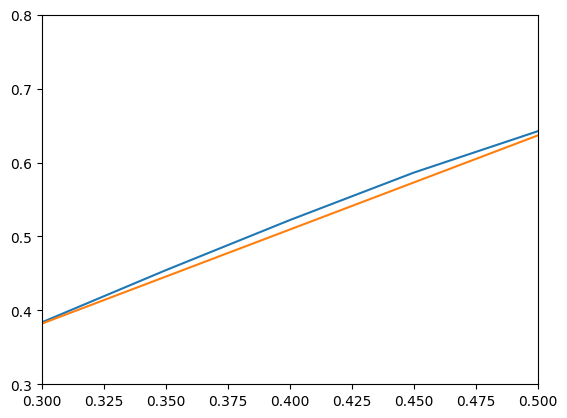

(0.3, 0.8)

In [195]:
plot((0.3:0.05:1), drude_sigma)
plot((0.3:0.05:1), (0.3:0.05:1)*4/pi)
xlim(0.3, 0.5)
ylim(0.3, 0.8)

In [196]:
pwd()

"/home/gridsan/aligho/Plasmons/Plasmons_Paper/Substitutional_Defects/Graphene"

In [193]:
np.savetxt("graphene_drude_sigma_0.3.txt", drude_sigma)

In [138]:
np.savetxt("graphene_sigma_0.3.txt", real(sigma))

In [194]:
sigma = np.loadtxt("graphene_sigma_0.3.txt");
drude_sigma = np.loadtxt("graphene_drude_sigma_0.3.txt");

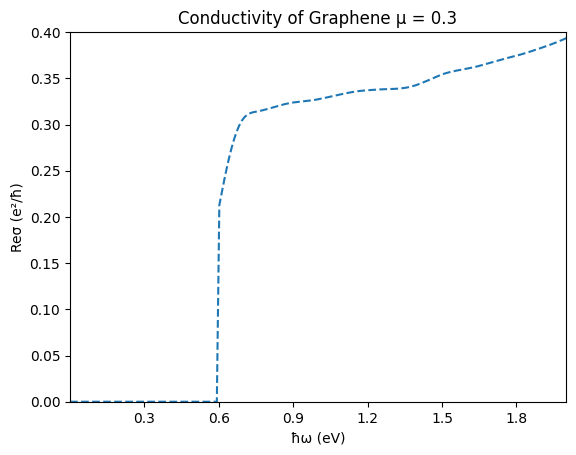

(PyObject[PyObject <matplotlib.axis.XTick object at 0x7f23eaf803d0>, PyObject <matplotlib.axis.XTick object at 0x7f23eaf803a0>, PyObject <matplotlib.axis.XTick object at 0x7f23ead28eb0>, PyObject <matplotlib.axis.XTick object at 0x7f23eafa60d0>, PyObject <matplotlib.axis.XTick object at 0x7f23eafa64f0>, PyObject <matplotlib.axis.XTick object at 0x7f23eafa6940>], PyObject[PyObject Text(0.3, 0, '0.3'), PyObject Text(0.6, 0, '0.6'), PyObject Text(0.9, 0, '0.9'), PyObject Text(1.2, 0, '1.2'), PyObject Text(1.5, 0, '1.5'), PyObject Text(1.8, 0, '1.8')])

In [155]:
plot(range(0, 3, length=300), [sigma[1:60]..., smooth(sigma[61:end], win_len=30)...] ./4, linestyle="dashed")
xlim(0, 2)
ylim(0, 0.4)
ylabel("Reσ (e²/ħ)")
xlabel("ħω (eV)")
title("Conductivity of Graphene μ = 0.3")
xticks([0.3, 0.6, 0.9, 1.2, 1.5, 1.8])

In [9]:
force_matrix, cellph_map = phonon_force_matrix("graphene");
phonon_bands = phonon_dispersion(force_matrix, cellph_map, return_negative=true);

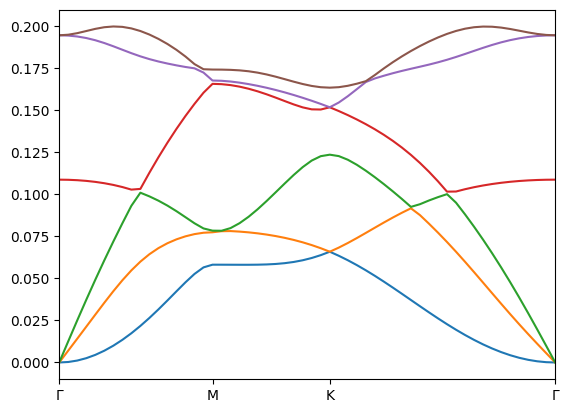

(0.0, 55.0)

In [10]:
plot(phonon_bands)
label_plots()

In [292]:
function ImΠGraphene(Hwannier::Array{Float64, 3}, cell_map::Array{Float64, 2}, lattice_vectors::Vector{<:Vector{<:Real}}, q::Vector{<:Real}, μ::Real, dim::Val{D}=Val(2); 
    degeneracy::Integer=1, mesh::Integer=100, num_blocks::Integer, 
        subsampling::Integer =10, histogram_width::Integer=100, monte_carlo::Bool = false, verbose::Bool=true, normalized::Bool=true) where D

    verbose && println(q); flush(stdout)
    Polarization_Array=zeros(histogram_width*100)
    V = 
        if D == 2 
            unit_cell_area(lattice_vectors) 
        elseif D ==3
            unit_cell_volume(lattice_vectors)
        end

    qnormalized = normalized ? q : normalize_kvector(lattice_vectors, q)

    for _ in 1:num_blocks
        kpoints =  (vcat(rand(D, mesh^D), zeros(3-D, mesh^D)) .- [1/2, 1/2, 0]) ./ subsampling .+ [2/3, -1/3, 0]

        kplusqpoints = reshape(repeat(qnormalized, mesh^D), (3, mesh^D)) + kpoints

        Eks, Uks = wannier_bands(Hwannier, cell_map, kpoints)
        Ekqs, Ukqs = wannier_bands(Hwannier, cell_map, kplusqpoints)
        
        numbands = size(Eks)[2]
        overlaps = np.einsum("lji, ljk -> lik", np.conj(Uks), Ukqs) # l indexes the k point, i and k index the band indices
        overlaps = overlaps .* np.conj(overlaps) # lij component is |<i, k_l| j, k_l+q>|^2

        Ekqs_reshaped = np.repeat(np.reshape(Ekqs, (mesh^D, 1, numbands)), numbands, axis=1)
        Eks_reshaped = np.repeat(np.reshape(Eks, (mesh^D, numbands, 1)), numbands, axis=2)
        omegas = Ekqs_reshaped - Eks_reshaped # lij component is E(k_l + q)_j - E(k_l)_i

        f2 = np.heaviside(μ .- Ekqs_reshaped, 0.5)
        f1 = np.heaviside(μ .- Eks_reshaped, 0.5)

        summand = (f2 - f1) .* overlaps

        Polarization_Array += first(np.histogram(omegas, bins=round(Int, histogram_width*100), 
                weights=summand, range=(0, 100)))*π/V*1/(subsampling)^2*(1/mesh)^D*histogram_width*degeneracy*(1/num_blocks)
    end
    return Polarization_Array
end


ImΠGraphene (generic function with 2 methods)

In [255]:
dirac_point

-4.225963500376079

In [419]:
μ = dirac_point + 0.5
impolarizations = []
N=20
for i in 1:N
    println(i); flush(stdout)
    push!(impolarizations, real.(ImΠGraphene(Hwannier, cell_map, lattice_vectors, [i/N*(μ-dirac_point)/6, 0, 0], μ,
                monte_carlo=true, normalized=false, histogram_width=10000, degeneracy=4, mesh=64, num_blocks=20)))
end

1
[0.004166666666666667, 0.0, 0.0]
2
[0.008333333333333333, 0.0, 0.0]
3
[0.012499999999999999, 0.0, 0.0]
4
[0.016666666666666666, 0.0, 0.0]
5
[0.020833333333333332, 0.0, 0.0]
6
[0.024999999999999998, 0.0, 0.0]
7
[0.029166666666666664, 0.0, 0.0]
8
[0.03333333333333333, 0.0, 0.0]
9
[0.0375, 0.0, 0.0]
10
[0.041666666666666664, 0.0, 0.0]
11
[0.04583333333333334, 0.0, 0.0]
12
[0.049999999999999996, 0.0, 0.0]
13
[0.05416666666666667, 0.0, 0.0]
14
[0.05833333333333333, 0.0, 0.0]
15
[0.0625, 0.0, 0.0]
16
[0.06666666666666667, 0.0, 0.0]
17
[0.07083333333333333, 0.0, 0.0]
18
[0.075, 0.0, 0.0]
19
[0.07916666666666666, 0.0, 0.0]
20
[0.08333333333333333, 0.0, 0.0]


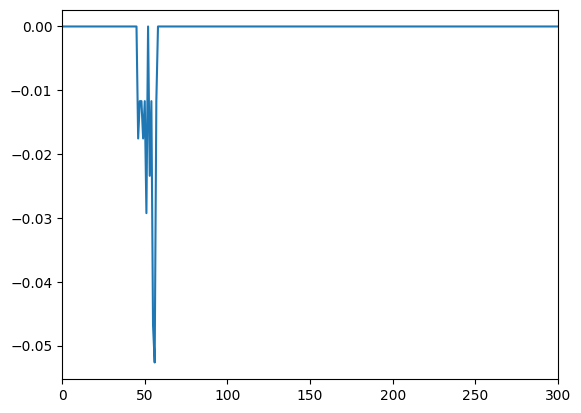

(0.0, 300.0)

In [359]:
plot(smooth(impolarizations[1], win_len=1))
xlim(0, 3*100)

In [328]:
μ-dirac_point

1.0

In [420]:
omegarange = 0:(μ-dirac_point)/10:2*(μ-dirac_point)
epsilons = zeros(ComplexF64, (length(impolarizations), length(omegarange)))
for i in 1:N
    println(i); flush(stdout)
    impol = smooth(impolarizations[i], win_len=30)
    for (j, ω) in enumerate(omegarange)
        epsilons[i, j] = ϵ([i/N*(μ-dirac_point)/6, 0, 0], lattice_vectors, ω, collect(range(0, 100, length=1000000)), 
            impol, normalized=false, δ=0.01)
    end
end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


0.75

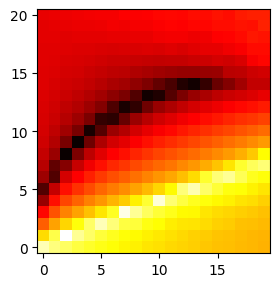

PyObject <matplotlib.image.AxesImage object at 0x7fe3f6cf2070>

In [421]:
figure(figsize=(3, 10))
imshow(transpose(log.(abs.(epsilons))), cmap="hot", origin="lower")

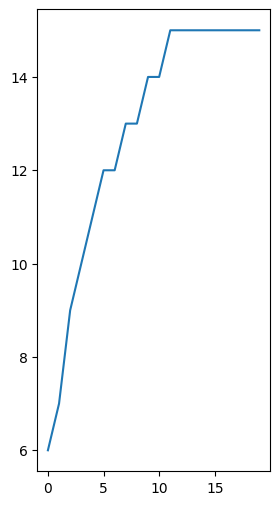

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7fe3f6cb7b80>

In [422]:
figure(figsize=(3, 6))
plot(smooth([argmin(x) for x in eachrow(log.(abs.(epsilons)))], win_len=30))

In [396]:
sqrt(1/60*(e²ϵ/2/π))

0.694083442258579

In [89]:
subsampling = returnfermikpoint(Hwannier, cell_map, -4.226+0.5, Val(2), mesh=30, num_blocks=1000, histogram_width=10)

(Real[0.6838510966643023 0.34310195008669475 … 0.3545548341126521 0.31838265999934445; 0.6824438363408329 0.35966222459239994 … 0.29339211359580575 0.3152724448774611; 0.0 0.0 … 0.0 0.0], 0.003061111111111111)

In [91]:
JJDFTX.dosatmu(Hwannier, cell_map, -4.226+0.5, mesh=20, num_blocks=600, histogram_width=10 )

0.0285

In [90]:
subsampling[1]

3×2755 Matrix{Real}:
 0.683851  0.343102  0.630916  0.635164  …  0.330923  0.354555  0.318383
 0.682444  0.359662  0.688454  0.688289     0.303458  0.293392  0.315272
 0.0       0.0       0.0       0.0          0.0       0.0       0.0

In [71]:
(.0263-0.02456)/0.02456*100

7.084690553745937

In [67]:
5.245957679219971/pi*1/5.83*1/5.83*0.5

0.024564492993263853

In [66]:
3/2*1.44*2.7

5.832000000000001

In [95]:
tau =  τ(Hwannier, cell_map, Pwannier, force_matrix, cellph_map,
    Heph, celleph_map, collect(0.01:0.01:1), -4.226+0.5, Val(2);supplysampling=subsampling, supplydos = 0.0285, histogram_width=100, mesh=64, num_blocks=3, fracroom=1)

DOS at Fermi Energy is: 0.0285
Sampling from 2755kpoints
Block: 1
Block: 2
Block: 3


100-element Vector{Float64}:
 2778.0243236560027
 2264.361967574971
 1848.5761568336056
 1510.785540345507
 1235.505837993433
 1010.6846350534355
  826.9007133387911
  676.7175111436856
  554.1797921347422
  454.43899021563504
  373.4873609249356
  307.9768302206371
  255.09756672327498
    ⋮
   14.174786497447913
   14.111139353786275
   14.049220491252584
   13.988960457887279
   13.930293473831743
   13.873157191802788
   13.817492476074337
   13.763243198319243
   13.710356048829519
   13.658780361780366
   13.608467953333902
   13.559372971495344

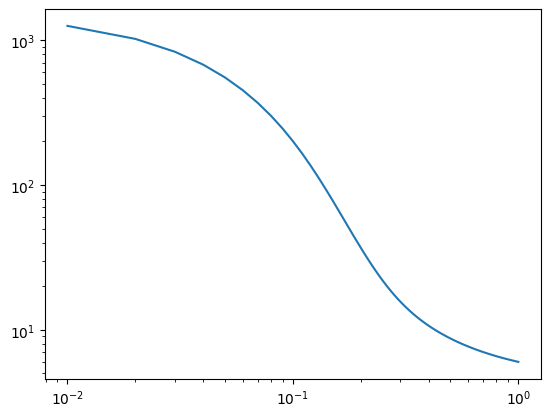

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7efd1a7a7190>

In [93]:
loglog(collect(0.01:0.01:1), tau)


In [78]:
Heph

3.348207297087884e-7

In [61]:
tau =  tauinverse(Hwannier, cellmap, Pwannier, force_matrix, cell_map,
    heph, cellmapeph, collect(0.01:0.01:1), dirac_point+0.5, 7;supplysampling=([x..., x1...], y+y1), supplydos = 0.029, histogram_width=100, mesh=20, mesh2=1000, fracroom=1)

DOS at Fermi Energy is: 0.029Sampling from 383kpoints


100-element Vector{Float64}:
 7.350988127031073e11
 7.973153274258724e11
 8.718976077982253e11
 9.615201716178081e11
 1.0693866533431884e12
 1.1992689854291543e12
 1.3555120812681917e12
 1.5429868751147776e12
 1.7669738449431445e12
 2.0329615332678132e12
 2.346351673975141e12
 2.7120754365723433e12
 3.1341436667796196e12
 ⋮
 2.8707997503063395e13
 2.8784865037754965e13
 2.8860043176082184e13
 2.8933587007056367e13
 2.900554925026869e13
 2.907598038192419e13
 2.914492875291385e13
 2.9212440699508227e13
 2.9278560647203953e13
 2.934333120821225e13
 2.9406793273038703e13
 2.9468986096568617e13

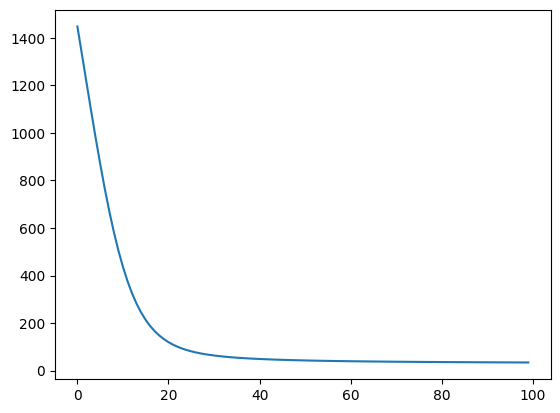

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7faef46c4190>

In [51]:
plot( 1e15 ./ tau)

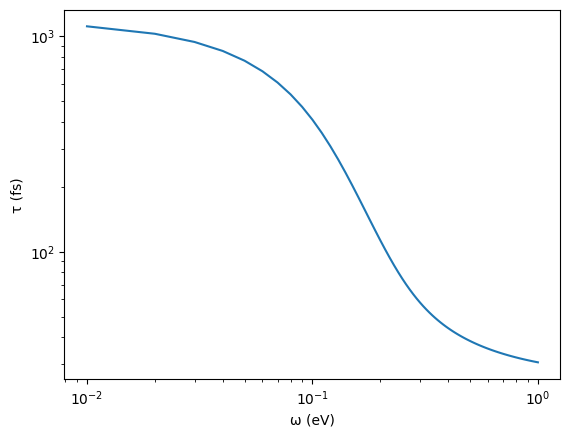

(PyObject[PyObject <matplotlib.axis.XTick object at 0x7fbf84fbb9a0>, PyObject <matplotlib.axis.XTick object at 0x7fbf84fbb370>, PyObject <matplotlib.axis.XTick object at 0x7fbf84fbccd0>], PyObject[PyObject Text(0.01, 0, '$\\mathdefault{10^{-2}}$'), PyObject Text(0.1, 0, '$\\mathdefault{10^{-1}}$'), PyObject Text(1.0, 0, '$\\mathdefault{10^{0}}$')])

In [136]:
loglog(collect(0.01:0.01:1), 1e15 ./ tau)
ylabel("τ (fs)")
xlabel("ω (eV)")
xticks([0.01, 0.1, 1])
#ylim(0, 100)

In [107]:
?loglog

search: loglog Clonglong Culonglong levitov_kramers_kronig_epsilon



Make a plot with log scaling on both the x and y axis.

Call signatures::

    loglog([x], y, [fmt], data=None, **kwargs)
    loglog([x], y, [fmt], [x2], y2, [fmt2], ..., **kwargs)

This is just a thin wrapper around `.plot` which additionally changes
both the x-axis and the y-axis to log scaling. All of the concepts and
parameters of plot can be used here as well.

The additional parameters *base*, *subs* and *nonpositive* control the
x/y-axis properties. They are just forwarded to `.Axes.set_xscale` and
`.Axes.set_yscale`. To use different properties on the x-axis and the
y-axis, use e.g.
``ax.set_xscale("log", base=10); ax.set_yscale("log", base=2)``.

Parameters
----------
base : float, default: 10
    Base of the logarithm.

subs : sequence, optional
    The location of the minor ticks. If *None*, reasonable locations
    are automatically chosen depending on the number of decades in the
    plot. See `.Axes.set_xscale`/`.Axes.set_yscale` for details.

nonpositive : {'mask', 'clip